# Lab Assignment: Market Basket Analysis using Apriori and FP-Growth

## Objective
The goal of this lab is to perform market basket analysis on a transactional retail dataset using two frequent itemset mining algorithms: **Apriori** and **FP-Growth**. After identifying frequent itemsets, association rules will be generated and analyzed using metrics such as **support**, **confidence**, and **lift**.

## Dataset Chosen
For this lab, I use the **Online Retail dataset**. This dataset contains transaction-level retail purchase records and is suitable for frequent itemset mining because it includes invoice numbers and item descriptions.

## Lab Workflow
This notebook is organized into the following steps:

1. **Data Preparation**
2. **Frequent Itemset Mining using Apriori**
3. **Frequent Itemset Mining using FP-Growth**
4. **Association Rule Generation and Analysis**
5. **Comparative Analysis**


In [9]:
# Install required packages if needed
!pip install ucimlrepo mlxtend seaborn openpyxl -q

## Importing Required Libraries

In this step, I import all the libraries needed for data loading, cleaning, visualization, and frequent pattern mining.

- **pandas** is used for data manipulation
- **seaborn** and **matplotlib** are used for visualization
- **mlxtend** provides implementations of Apriori, FP-Growth, and association rule mining
- **time** is used to compare the execution time of both algorithms

In [10]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Step 1: Data Preparation

The first step in market basket analysis is to prepare the transactional dataset in a clean and usable format.

The Online Retail dataset contains invoice-level records, where each row corresponds to a purchased item in a transaction. However, before applying Apriori or FP-Growth, the data must be cleaned.

The following cleaning steps are performed:

1. Remove cancelled transactions
2. Remove rows with missing or invalid item descriptions
3. Remove rows with non-positive quantity or price
4. Keep a country-based subset to reduce sparsity and improve mining performance
5. Convert transaction data into a one-hot encoded basket matrix

This basket matrix is required because both Apriori and FP-Growth work on binary transaction-item data.

In [11]:
# Load the dataset
online_retail = fetch_ucirepo(id=352)
df = pd.concat([online_retail.data.features, online_retail.data.ids], axis=1)

print("Original shape of dataset:", df.shape)
display(df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Original shape of dataset: (541909, 8)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365,85123A
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,71053
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365,84406B
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029G
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029E


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
# Standardize column types and clean text fields
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["Description"] = df["Description"].astype(str).str.strip()
df["Country"] = df["Country"].astype(str).str.strip()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Cleaning the Dataset

The raw data may contain transactions that are not useful for pattern mining.

The following rows are removed:

- Cancelled invoices
- Blank or missing item descriptions
- Rows with zero or negative quantity
- Rows with zero or negative unit price

These cleaning steps help ensure that only valid purchase transactions remain in the final dataset.

In [13]:
# Remove cancelled invoices
df = df[~df["InvoiceNo"].str.startswith("C", na=False)]

# Remove invalid descriptions
df = df[df["Description"].notna()]
df = df[df["Description"] != ""]
df = df[df["Description"].str.lower() != "nan"]

# Remove invalid quantity and price rows
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("Shape after cleaning:", df.shape)
display(df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Shape after cleaning: (530104, 8)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365,85123A
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,71053
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365,84406B
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029G
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029E


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Exploring the Country Distribution

The dataset contains transactions from multiple countries.  
Since the full dataset can become very sparse and computationally expensive for frequent pattern mining, it is practical to work with a single-country subset.

This helps make the basket matrix smaller and easier to process while still preserving meaningful purchasing patterns.

In [14]:
country_counts = df["Country"].value_counts().head(10)
display(country_counts)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
Country,
United Kingdom,485123
Germany,9040
France,8407
EIRE,7890
Spain,2484
Netherlands,2359
Belgium,2031
Switzerland,1966
Portugal,1501


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Selecting a Country Subset

For this notebook, I use transactions from **France**.  
This gives a manageable transaction subset and still contains enough repeated item purchases to make association rule mining meaningful.

In [15]:
df_country = df[df["Country"] == "France"].copy()

print("Selected country: France")
print("Number of rows:", df_country.shape[0])
print("Number of unique invoices:", df_country["InvoiceNo"].nunique())
print("Number of unique items:", df_country["Description"].nunique())

display(df_country.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Selected country: France
Number of rows: 8407
Number of unique invoices: 392
Number of unique items: 1563


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode
26,ALARM CLOCK BAKELIKE PINK,24,12/1/2010 8:45,3.75,12583.0,France,536370,22728
27,ALARM CLOCK BAKELIKE RED,24,12/1/2010 8:45,3.75,12583.0,France,536370,22727
28,ALARM CLOCK BAKELIKE GREEN,12,12/1/2010 8:45,3.75,12583.0,France,536370,22726
29,PANDA AND BUNNIES STICKER SHEET,12,12/1/2010 8:45,0.85,12583.0,France,536370,21724
30,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583.0,France,536370,21883


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Creating the Basket Matrix

To apply Apriori and FP-Growth, the data must be transformed into a **transaction-item matrix**.

In this matrix:

- Each row represents one invoice
- Each column represents one item
- A value of **1** means the item was purchased in that transaction
- A value of **0** means the item was not purchased

This binary matrix is also called a **one-hot encoded basket matrix**.

In [16]:
basket = (
    df_country.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = basket.apply(lambda col: col.map(lambda x: 1 if x > 0 else 0)).astype(bool)

print("Basket matrix shape:", basket.shape)
display(basket.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Basket matrix shape: (392, 1563)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536370,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536852,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536974,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
537065,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
537463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Step 1 Visualizations: Exploring the Dataset

Before mining frequent itemsets, it is useful to understand the basic structure of the transaction data.

Two visualizations are created:

1. A **bar plot** showing the most frequently occurring items
2. A **heatmap** showing how often top items appear together in the same transaction

These plots help identify common products and strong item co-occurrence patterns even before formal rule mining.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

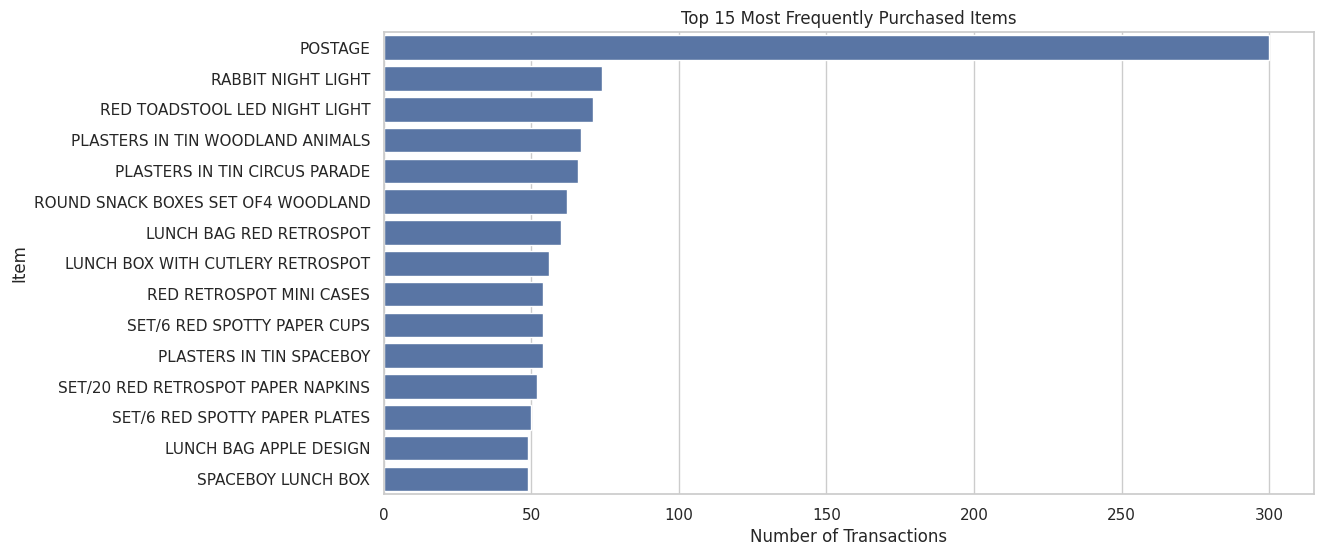

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
item_frequencies = basket.sum().sort_values(ascending=False)
top_n = 15
top_items = item_frequencies.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.values, y=top_items.index)
plt.title("Top 15 Most Frequently Purchased Items")
plt.xlabel("Number of Transactions")
plt.ylabel("Item")
plt.show()

## Interpretation of the Item Frequency Plot

The bar plot shows which items appear most often across all transactions.

Items with high transaction frequency are important because:

- They are likely to appear in frequent itemsets
- They may play a central role in association rules
- They represent commonly purchased products in the selected subset

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

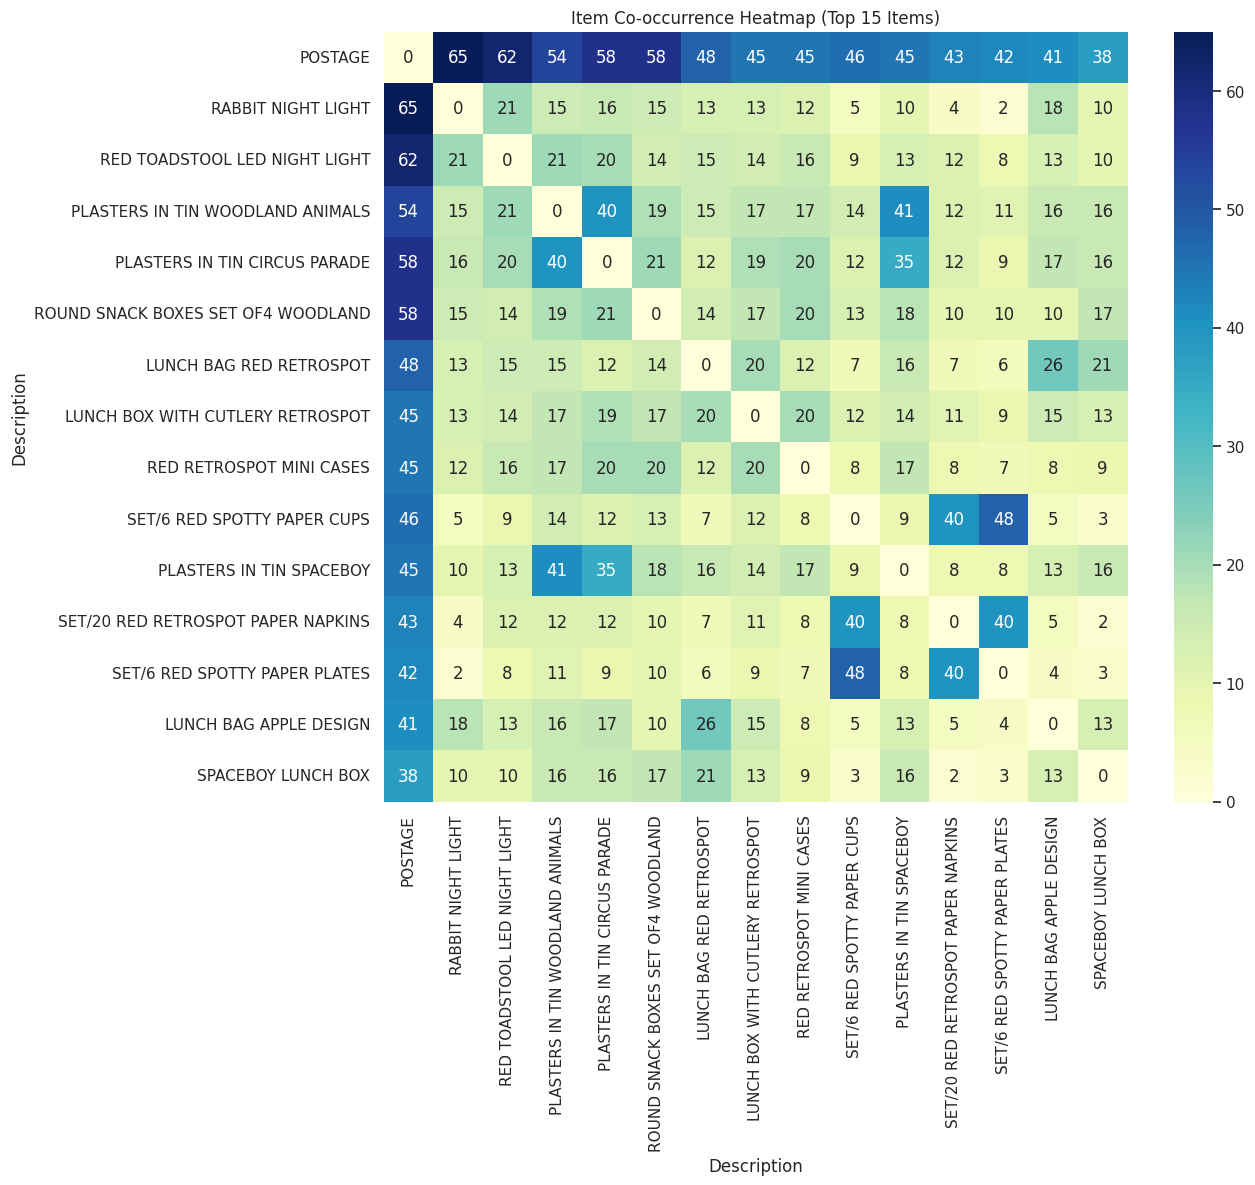

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
top_item_names = top_items.index.tolist()
co_occurrence = basket[top_item_names].astype(int).T.dot(basket[top_item_names].astype(int))

np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Item Co-occurrence Heatmap (Top 15 Items)")
plt.show()

## Interpretation of the Co-occurrence Heatmap

The heatmap shows how often pairs of top items occur together in the same transaction.

Stronger co-occurrence values suggest:

- A possible shopping pattern
- A strong relationship between products
- Potential association rules with good confidence or lift

This visual exploration helps confirm that the dataset is suitable for market basket analysis.

# Step 2: Frequent Itemset Mining Using Apriori

Apriori is one of the most well-known algorithms for finding frequent itemsets.

It works by:

1. Finding frequent single items
2. Using those to generate candidate pairs
3. Then generating larger itemsets step by step
4. Removing itemsets that do not satisfy the minimum support threshold

In this notebook, the minimum support threshold is set to **0.02**, which means an itemset must appear in at least 2% of all transactions to be considered frequent.

In [19]:
min_support = 0.02

start_time = time.perf_counter()
frequent_itemsets_apriori = apriori(
    basket,
    min_support=min_support,
    use_colnames=True
)
apriori_time = time.perf_counter() - start_time

frequent_itemsets_apriori["length"] = frequent_itemsets_apriori["itemsets"].apply(len)
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values(
    by=["support", "length"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Apriori runtime: {apriori_time:.4f} seconds")
print("Number of frequent itemsets found:", len(frequent_itemsets_apriori))
display(frequent_itemsets_apriori.head(20))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Apriori runtime: 0.3608 seconds
Number of frequent itemsets found: 2509


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets,length
0,0.765306,(POSTAGE),1
1,0.188776,(RABBIT NIGHT LIGHT),1
2,0.181122,(RED TOADSTOOL LED NIGHT LIGHT),1
3,0.170918,(PLASTERS IN TIN WOODLAND ANIMALS),1
4,0.168367,(PLASTERS IN TIN CIRCUS PARADE),1
5,0.165816,"(POSTAGE, RABBIT NIGHT LIGHT)",2
6,0.158163,(ROUND SNACK BOXES SET OF4 WOODLAND),1
7,0.158163,"(POSTAGE, RED TOADSTOOL LED NIGHT LIGHT)",2
8,0.153061,(LUNCH BAG RED RETROSPOT),1
9,0.147959,"(POSTAGE, PLASTERS IN TIN CIRCUS PARADE)",2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Understanding the Apriori Output

The output contains:

- **itemsets**: the frequent item combinations
- **support**: the proportion of transactions containing the itemset
- **length**: the number of items in the itemset

Higher support values indicate more commonly occurring itemsets.

At this stage, the frequent itemsets only show which products appear together often.  
The next step will later convert these itemsets into association rules.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

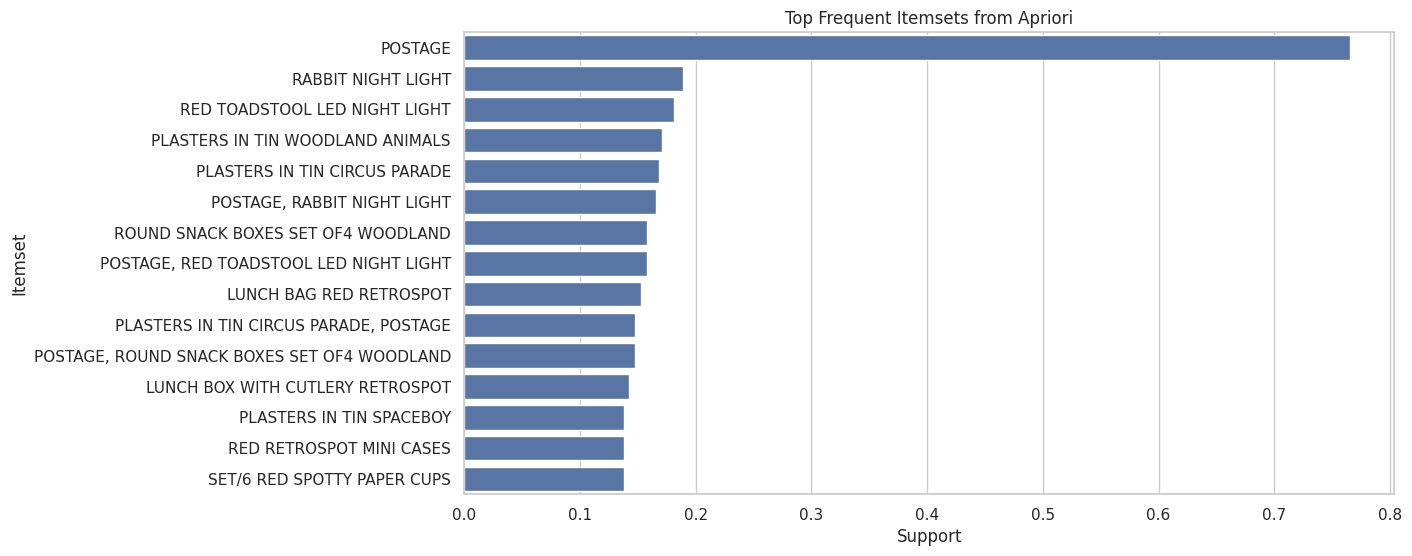

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
top_apriori = frequent_itemsets_apriori.head(15).copy()
top_apriori["itemset_str"] = top_apriori["itemsets"].apply(lambda x: ", ".join(sorted(list(x))))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_apriori, x="support", y="itemset_str")
plt.title("Top Frequent Itemsets from Apriori")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.show()

## Interpretation of Apriori Frequent Itemsets

This bar plot highlights the most frequent itemsets discovered by Apriori.

In general:

- Single-item itemsets often have the highest support
- Multi-item itemsets are more useful for rule generation
- These patterns reflect repeated customer purchase behavior

# Step 3: Frequent Itemset Mining Using FP-Growth

FP-Growth is another algorithm used to find frequent itemsets.

Unlike Apriori, FP-Growth does not generate candidate itemsets level by level.  
Instead, it compresses the dataset into a structure called an **FP-tree** and mines patterns more efficiently.

To make the comparison fair, the same minimum support threshold used for Apriori is also used here.

In [21]:
start_time = time.perf_counter()
frequent_itemsets_fpgrowth = fpgrowth(
    basket,
    min_support=min_support,
    use_colnames=True
)
fpgrowth_time = time.perf_counter() - start_time

frequent_itemsets_fpgrowth["length"] = frequent_itemsets_fpgrowth["itemsets"].apply(len)
frequent_itemsets_fpgrowth = frequent_itemsets_fpgrowth.sort_values(
    by=["support", "length"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"FP-Growth runtime: {fpgrowth_time:.4f} seconds")
print("Number of frequent itemsets found:", len(frequent_itemsets_fpgrowth))
display(frequent_itemsets_fpgrowth.head(20))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

FP-Growth runtime: 7.0731 seconds
Number of frequent itemsets found: 2509


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets,length
0,0.765306,(POSTAGE),1
1,0.188776,(RABBIT NIGHT LIGHT),1
2,0.181122,(RED TOADSTOOL LED NIGHT LIGHT),1
3,0.170918,(PLASTERS IN TIN WOODLAND ANIMALS),1
4,0.168367,(PLASTERS IN TIN CIRCUS PARADE),1
5,0.165816,"(POSTAGE, RABBIT NIGHT LIGHT)",2
6,0.158163,(ROUND SNACK BOXES SET OF4 WOODLAND),1
7,0.158163,"(POSTAGE, RED TOADSTOOL LED NIGHT LIGHT)",2
8,0.153061,(LUNCH BAG RED RETROSPOT),1
9,0.147959,"(ROUND SNACK BOXES SET OF4 WOODLAND, POSTAGE)",2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Understanding the FP-Growth Output

FP-Growth returns the same type of output as Apriori:

- frequent itemsets
- support values
- itemset lengths

Since the same support threshold is used, the results should be very similar in terms of the patterns discovered.

The main difference between the two algorithms is usually the **runtime efficiency**.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

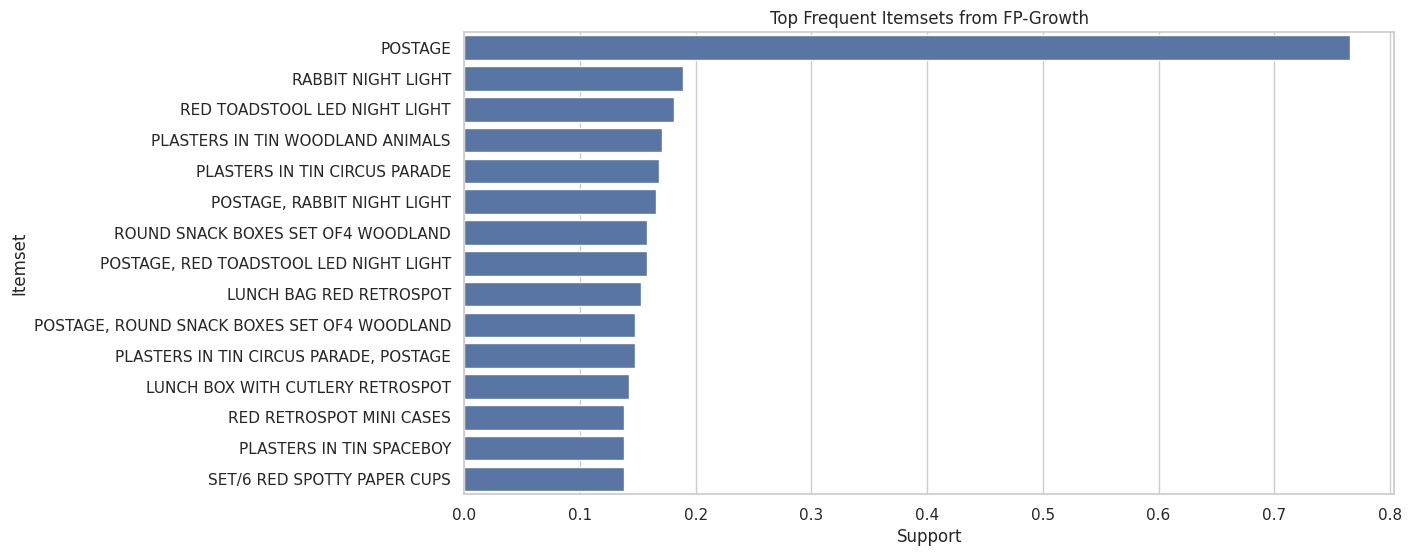

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
top_fpgrowth = frequent_itemsets_fpgrowth.head(15).copy()
top_fpgrowth["itemset_str"] = top_fpgrowth["itemsets"].apply(lambda x: ", ".join(sorted(list(x))))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_fpgrowth, x="support", y="itemset_str")
plt.title("Top Frequent Itemsets from FP-Growth")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.show()

## Interpretation of FP-Growth Frequent Itemsets

This plot shows the top frequent itemsets found using FP-Growth.

If both algorithms are working correctly with the same support threshold, the top itemsets from FP-Growth should closely match those from Apriori.

This allows a fair comparison between correctness and performance.

In [23]:
ap_set = set(
    (frozenset(x), round(s, 6))
    for x, s in zip(frequent_itemsets_apriori["itemsets"], frequent_itemsets_apriori["support"])
)

fp_set = set(
    (frozenset(x), round(s, 6))
    for x, s in zip(frequent_itemsets_fpgrowth["itemsets"], frequent_itemsets_fpgrowth["support"])
)

print("Do both algorithms return the same frequent itemsets?", ap_set == fp_set)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Do both algorithms return the same frequent itemsets? True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Comparing Frequent Itemset Outputs

This check confirms whether Apriori and FP-Growth produced the same frequent itemsets and support values.

If the result is **True**, it means both algorithms discovered the same patterns for the given support threshold.  
This is expected in most cases when both are applied correctly to the same basket matrix.

# Step 4: Generating and Analyzing Association Rules

Frequent itemsets show which products are often purchased together, but they do not directly explain relationships such as:

- If a customer buys item A, what is the chance they also buy item B?

To answer this, association rules are generated.

I have usded minimum confidence threshold of **0.40**.

The most important rule metrics are:

- **Support**: How often the rule occurs in the dataset
- **Confidence**: How often the consequent is bought when the antecedent is bought
- **Lift**: How much stronger the relationship is compared to random chance

A lift value greater than 1 suggests a positive association.

In [24]:
min_confidence = 0.40

rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric="confidence",
    min_threshold=min_confidence
)

rules_apriori = rules_apriori.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("Number of association rules generated from Apriori itemsets:", len(rules_apriori))
display(rules_apriori[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of association rules generated from Apriori itemsets: 6732


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,"(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...","(SET/6 RED SPOTTY PAPER PLATES, ALARM CLOCK BA...",0.020408,0.800000,39.200000
1,"(SET/6 RED SPOTTY PAPER PLATES, ALARM CLOCK BA...","(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...",0.020408,1.000000,39.200000
2,"(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...","(ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY P...",0.020408,0.888889,38.716049
3,"(ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY P...","(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...",0.020408,0.888889,38.716049
4,"(DOLLY GIRL CHILDRENS CUP, POSTAGE, SPACEBOY C...","(DOLLY GIRL CHILDRENS BOWL, SPACEBOY CHILDRENS...",0.025510,1.000000,35.636364
5,"(DOLLY GIRL CHILDRENS BOWL, SPACEBOY CHILDRENS...","(DOLLY GIRL CHILDRENS CUP, POSTAGE, SPACEBOY C...",0.025510,0.909091,35.636364
6,(RECYCLED ACAPULCO MAT LAVENDER),"(POSTAGE, RECYCLED ACAPULCO MAT RED)",0.020408,0.800000,34.844444
7,(RECYCLED ACAPULCO MAT LAVENDER),"(RECYCLED ACAPULCO MAT TURQUOISE, RECYCLED ACA...",0.020408,0.800000,34.844444
8,"(POSTAGE, RECYCLED ACAPULCO MAT RED)",(RECYCLED ACAPULCO MAT LAVENDER),0.020408,0.888889,34.844444
9,"(RECYCLED ACAPULCO MAT TURQUOISE, RECYCLED ACA...",(RECYCLED ACAPULCO MAT LAVENDER),0.020408,0.888889,34.844444


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Interpreting the Association Rules

Each rule has the form:

**Antecedent -> Consequent**

This means that when the antecedent itemset appears in a transaction, the consequent itemset is also likely to appear.

Important points when reading the rules:

- High **confidence** means the rule is reliable
- High **lift** means the association is stronger than chance
- Higher **support** means the rule is more common in the dataset

In [25]:
rules_fpgrowth = association_rules(
    frequent_itemsets_fpgrowth,
    metric="confidence",
    min_threshold=min_confidence
)

rules_fpgrowth = rules_fpgrowth.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("Number of association rules generated from FP-Growth itemsets:", len(rules_fpgrowth))
display(rules_fpgrowth[["antecedents", "consequents", "support", "confidence", "lift"]].head(20))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of association rules generated from FP-Growth itemsets: 6732


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,"(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...","(SET/6 RED SPOTTY PAPER PLATES, ALARM CLOCK BA...",0.020408,0.800000,39.200000
1,"(SET/6 RED SPOTTY PAPER PLATES, ALARM CLOCK BA...","(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...",0.020408,1.000000,39.200000
2,"(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...","(ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY P...",0.020408,0.888889,38.716049
3,"(ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY P...","(SET/6 RED SPOTTY PAPER CUPS, ALARM CLOCK BAKE...",0.020408,0.888889,38.716049
4,"(DOLLY GIRL CHILDRENS CUP, POSTAGE, SPACEBOY C...","(DOLLY GIRL CHILDRENS BOWL, SPACEBOY CHILDRENS...",0.025510,1.000000,35.636364
5,"(DOLLY GIRL CHILDRENS BOWL, SPACEBOY CHILDRENS...","(DOLLY GIRL CHILDRENS CUP, POSTAGE, SPACEBOY C...",0.025510,0.909091,35.636364
6,(RECYCLED ACAPULCO MAT LAVENDER),"(RECYCLED ACAPULCO MAT TURQUOISE, RECYCLED ACA...",0.020408,0.800000,34.844444
7,(RECYCLED ACAPULCO MAT LAVENDER),"(POSTAGE, RECYCLED ACAPULCO MAT RED)",0.020408,0.800000,34.844444
8,"(RECYCLED ACAPULCO MAT TURQUOISE, RECYCLED ACA...",(RECYCLED ACAPULCO MAT LAVENDER),0.020408,0.888889,34.844444
9,"(POSTAGE, RECYCLED ACAPULCO MAT RED)",(RECYCLED ACAPULCO MAT LAVENDER),0.020408,0.888889,34.844444


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Formatting Rules for Better Readability

By default, antecedents and consequents appear as Python set objects.  
To make the rules easier to read, they are converted into comma-separated text.

In [26]:
def format_rules(df_rules):
    df_rules = df_rules.copy()
    df_rules["antecedents"] = df_rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
    df_rules["consequents"] = df_rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
    return df_rules

rules_apriori_fmt = format_rules(rules_apriori)
rules_fpgrowth_fmt = format_rules(rules_fpgrowth)

display(rules_apriori_fmt[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,"ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY PA...","ALARM CLOCK BAKELIKE GREEN, SET/6 RED SPOTTY P...",0.020408,0.800000,39.200000
1,"ALARM CLOCK BAKELIKE GREEN, SET/6 RED SPOTTY P...","ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY PA...",0.020408,1.000000,39.200000
2,"ALARM CLOCK BAKELIKE GREEN, SET/6 RED SPOTTY P...","ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY PA...",0.020408,0.888889,38.716049
3,"ALARM CLOCK BAKELIKE PINK, SET/6 RED SPOTTY PA...","ALARM CLOCK BAKELIKE GREEN, SET/6 RED SPOTTY P...",0.020408,0.888889,38.716049
4,"DOLLY GIRL CHILDRENS CUP, POSTAGE, SPACEBOY CH...","DOLLY GIRL CHILDRENS BOWL, SPACEBOY CHILDRENS CUP",0.025510,1.000000,35.636364
5,"DOLLY GIRL CHILDRENS BOWL, SPACEBOY CHILDRENS CUP","DOLLY GIRL CHILDRENS CUP, POSTAGE, SPACEBOY CH...",0.025510,0.909091,35.636364
6,RECYCLED ACAPULCO MAT LAVENDER,"POSTAGE, RECYCLED ACAPULCO MAT RED",0.020408,0.800000,34.844444
7,RECYCLED ACAPULCO MAT LAVENDER,"RECYCLED ACAPULCO MAT RED, RECYCLED ACAPULCO M...",0.020408,0.800000,34.844444
8,"POSTAGE, RECYCLED ACAPULCO MAT RED",RECYCLED ACAPULCO MAT LAVENDER,0.020408,0.888889,34.844444
9,"RECYCLED ACAPULCO MAT RED, RECYCLED ACAPULCO M...",RECYCLED ACAPULCO MAT LAVENDER,0.020408,0.888889,34.844444


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Visualizing Rule Strength

A scatter plot of **confidence vs lift** provides a useful way to evaluate the quality of the generated rules.

In this plot:

- Rules farther to the right have higher confidence
- Rules higher on the chart have higher lift
- Larger points indicate higher support

This helps identify rules that are both reliable and meaningful.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

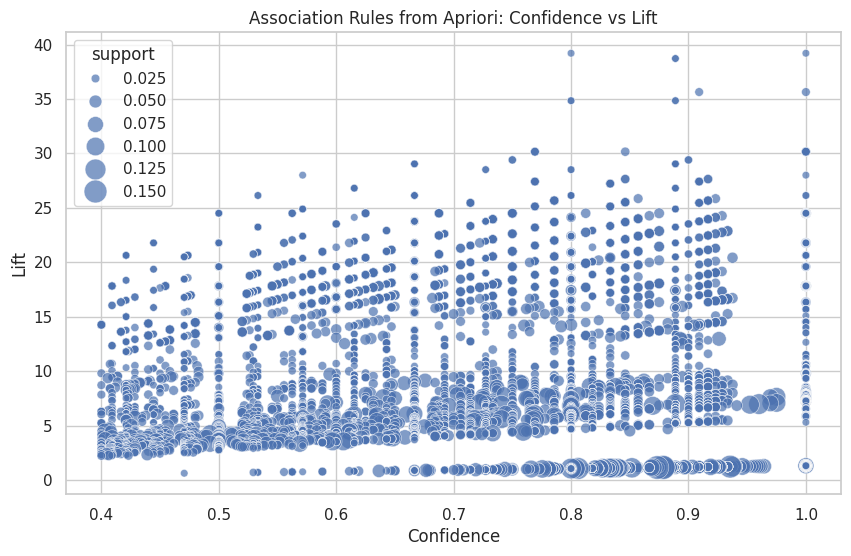

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rules_apriori,
    x="confidence",
    y="lift",
    size="support",
    sizes=(30, 300),
    alpha=0.7
)
plt.title("Association Rules from Apriori: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.show()

## Visualizing the Top Rules by Lift

Lift is one of the most useful rule quality measures because it shows whether two itemsets are associated more strongly than expected by chance.

The following plot highlights the top association rules with the highest lift values.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

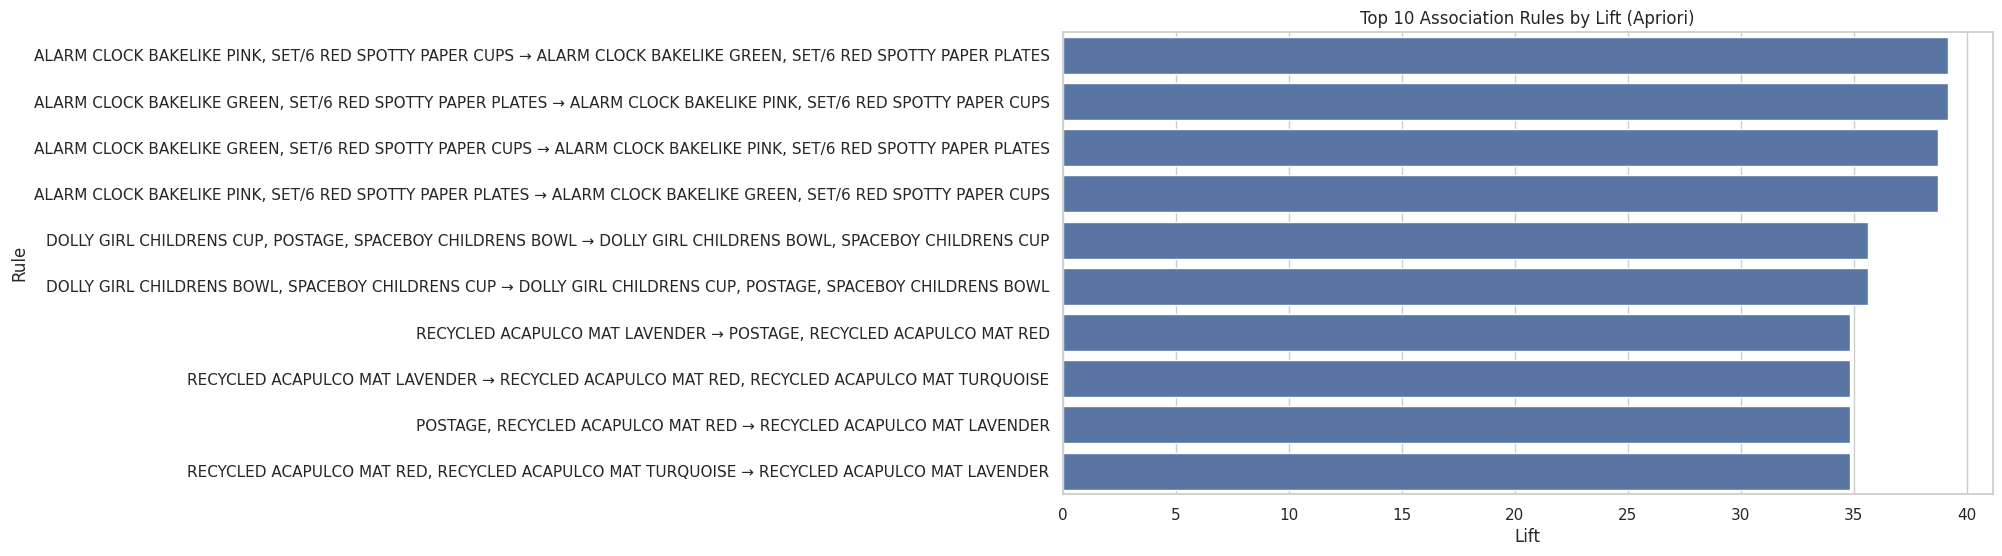

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [28]:
top_rules = rules_apriori_fmt.head(10).copy()
top_rules["rule"] = top_rules["antecedents"] + " → " + top_rules["consequents"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rules, x="lift", y="rule")
plt.title("Top 10 Association Rules by Lift (Apriori)")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.show()

## Rule Insights

From the generated rules, several meaningful patterns can be observed:

- Some products repeatedly appear together in the same invoice
- Certain items strongly imply the purchase of another item
- High-lift rules may be useful for product recommendation or bundle design

These patterns are valuable in retail because they can support:
- cross-selling
- shelf arrangement
- promotion planning
- recommendation systems

# Step 5: Comparative Analysis

In the final part of the lab, Apriori and FP-Growth are compared based on:

1. Execution time
2. Number of frequent itemsets found
3. Number of association rules generated
4. Practical performance on this dataset

This comparison helps show not only whether the algorithms produce similar outputs, but also which one is more efficient.

In [29]:
comparison_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Runtime (seconds)": [apriori_time, fpgrowth_time],
    "Frequent Itemsets": [len(frequent_itemsets_apriori), len(frequent_itemsets_fpgrowth)],
    "Association Rules": [len(rules_apriori), len(rules_fpgrowth)]
})

display(comparison_df)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Algorithm,Runtime (seconds),Frequent Itemsets,Association Rules
0,Apriori,0.360781,2509,6732
1,FP-Growth,7.073090,2509,6732


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Runtime Comparison

The following plot directly compares the runtime of Apriori and FP-Growth.

This is important because frequent pattern mining can become very expensive when the number of transactions and products increases.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

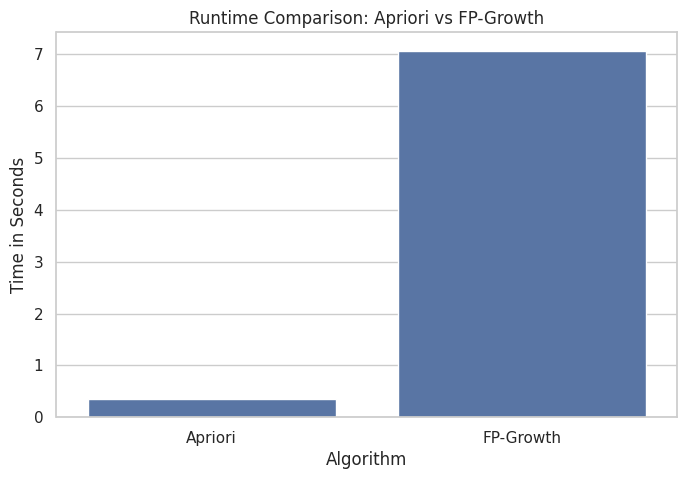

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Algorithm", y="Runtime (seconds)")
plt.title("Runtime Comparison: Apriori vs FP-Growth")
plt.ylabel("Time in Seconds")
plt.show()

# Final Discussion

## Comparison of Apriori and FP-Growth

Based on the results in this notebook:

- Both Apriori and FP-Growth produced the same or very similar frequent itemsets
- Both produced the same or very similar association rules
- FP-Growth was faster in execution time

This result is expected because FP-Growth avoids generating large numbers of candidate itemsets, while Apriori checks candidates level by level.

## Challenges Faced

Some challenges during this lab included:

- The original dataset was large and sparse
- The raw data included cancelled and invalid transactions
- Frequent pattern mining on the full dataset can become computationally expensive

These issues were handled by:

- cleaning the data carefully
- removing cancelled and invalid rows
- selecting a country subset
- converting the dataset into a binary basket matrix

## Conclusion

This lab showed me how market basket analysis can discover hidden purchasing patterns in retail transactions.

how Apriori is useful for understanding the basic idea of frequent itemset mining, but FP-Growth is usually more efficient for larger datasets.

Overall, the generated association rules revealed useful product relationships that could help support recommendation systems and business decision-making.

# Summary

In this lab, I performed market basket analysis using the Online Retail dataset.

First, the data was cleaned and transformed into a one-hot encoded transaction matrix.  
Then, frequent itemsets were generated using both Apriori and FP-Growth.  
After that, association rules were extracted and analyzed using support, confidence, and lift.  
Finally, both algorithms were compared in terms of output and runtime.

The results showed that both methods identified similar frequent patterns, but FP-Growth was more efficient.  
This demonstrates the practical value of frequent itemset mining in discovering meaningful purchasing behavior from transactional data.